# V17: Free Sorting MDS Map with Threshold Clustering

Reproduces the XLStat Free Sorting reference plot using Python:
- Loads raw free sorting data (panelists 2,4,5,6 — best version = Free Sorting7)
- Computes dissimilarity matrix from co-grouping frequency
- Applies MDS to get 2D consensus positions (validates against XLStat STATIS coords)
- Cuts hierarchical clustering at a **threshold** to define clusters
- Produces a labelled scatter map with confidence ellipses per cluster

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.manifold import MDS
from sklearn.preprocessing import normalize
import openpyxl
from pathlib import Path

EXCEL_PATH = Path('../free_sorting/Auswertung Best Of XLStat Erdbeere.xlsm')
OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# Color palette for clusters (colorblind-friendly)
CLUSTER_COLORS = [
    '#E63946',  # red
    '#457B9D',  # blue
    '#2A9D8F',  # teal
    '#E9C46A',  # yellow
    '#F4A261',  # orange
    '#A8DADC',  # light blue
    '#6A0572',  # purple
    '#264653',  # dark teal
]

## 1. Load Free Sorting Data

Sheet `Tabelle1 (7)` contains the best version (panelists P2, P4, P5, P6 — 3 sessions each = 12 columns).
Rows = 25 products (recipes), columns = 12 assessors.
Values = group numbers assigned by each assessor.

In [2]:
wb = openpyxl.load_workbook(EXCEL_PATH, keep_vba=True, data_only=True)
ws = wb['Tabelle1 (7)']

rows = list(ws.iter_rows(min_row=1, max_row=26, values_only=True))
header = rows[0]  # ('Rez.-Nr.', 'P2.1', 'P4.1', ...)
data_rows = [r for r in rows[1:] if r[0] is not None]

product_names = [r[0] for r in data_rows]
assessors = list(header[1:])
group_matrix = np.array([[r[i] for i in range(1, len(header))] for r in data_rows], dtype=float)

print(f'Products: {len(product_names)}')
print(f'Assessors: {len(assessors)}')
print(f'Matrix shape: {group_matrix.shape}')
print(f'Sample products: {product_names[:5]}')
print(f'Assessors: {assessors}')

Products: 25
Assessors: 12
Matrix shape: (25, 12)
Sample products: ['187.886P', '185.382P', '185.090P', '185.309P', '188.412P']
Assessors: ['P2.1', 'P4.1', 'P5.1', 'P6.1', 'P2.2', 'P4.2', 'P5.2', 'P6.2', 'P2.3', 'P4.3', 'P5.3', 'P6.3']


## 2. Compute Dissimilarity Matrix

For each pair of products (i, j) and each assessor:
- **Same group** → similarity +1
- **Different group** → similarity 0

Dissimilarity = 1 − (proportion of assessors who placed i and j together).
This is exactly what XLStat's free sorting analysis uses.

In [3]:
n = len(product_names)
n_assessors = group_matrix.shape[1]

co_occurrence = np.zeros((n, n))
for a in range(n_assessors):
    groups = group_matrix[:, a]
    for i in range(n):
        for j in range(n):
            if groups[i] == groups[j]:
                co_occurrence[i, j] += 1

# Similarity: proportion of assessors who grouped i and j together
similarity = co_occurrence / n_assessors
np.fill_diagonal(similarity, 1.0)  # products perfectly similar to themselves

# Dissimilarity: 1 - similarity
dissimilarity = 1.0 - similarity
np.fill_diagonal(dissimilarity, 0.0)

diss_df = pd.DataFrame(dissimilarity, index=product_names, columns=product_names)

print('Dissimilarity matrix (first 5x5):')
print(diss_df.iloc[:5, :5].round(3))
print(f'\nMin dissimilarity (excl. diagonal): {dissimilarity[dissimilarity > 0].min():.3f}')
print(f'Max dissimilarity: {dissimilarity.max():.3f}')

Dissimilarity matrix (first 5x5):
          187.886P  185.382P  185.090P  185.309P  188.412P
187.886P     0.000     0.417     0.917     1.000     1.000
185.382P     0.417     0.000     0.833     1.000     1.000
185.090P     0.917     0.833     0.000     0.833     0.583
185.309P     1.000     1.000     0.833     0.000     0.750
188.412P     1.000     1.000     0.583     0.750     0.000

Min dissimilarity (excl. diagonal): 0.167
Max dissimilarity: 1.000


## 3. MDS — 2D Consensus Map

Apply metric MDS on the dissimilarity matrix.  
We then compare with XLStat's STATIS consensus coordinates (Dim1, Dim2) to validate alignment.

In [4]:
# Metric MDS with precomputed dissimilarity
mds = MDS(
    n_components=2,
    dissimilarity='precomputed',
    metric=True,
    n_init=10,
    max_iter=1000,
    random_state=42,
    normalized_stress='auto',
)
coords = mds.fit_transform(dissimilarity)

print(f'MDS stress: {mds.stress_:.4f}')
print(f'\nMDS coordinates (first 5 products):')
for i in range(5):
    print(f'  {product_names[i]:15s}  Dim1={coords[i,0]:+.4f}  Dim2={coords[i,1]:+.4f}')

MDS stress: 15.3740

MDS coordinates (first 5 products):
  187.886P         Dim1=-0.3964  Dim2=-0.5295
  185.382P         Dim1=-0.4490  Dim2=-0.3735
  185.090P         Dim1=+0.3983  Dim2=+0.2755
  185.309P         Dim1=+0.3155  Dim2=+0.6159
  188.412P         Dim1=+0.5966  Dim2=-0.0603


/opt/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_mds.py:779: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


In [5]:
# Validate against XLStat STATIS coordinates
# Row 131 = Dim1/Dim2 header, rows 132-156 = product coordinates
ws_xlstat = wb['Free Sorting7']
xlstat_rows = list(ws_xlstat.iter_rows(min_row=132, max_row=157, values_only=True))

xlstat_products = []
xlstat_dim1 = []
xlstat_dim2 = []
for row in xlstat_rows:
    vals = [v for v in row if v is not None]
    if vals and isinstance(vals[0], str) and vals[0].strip() and isinstance(vals[1], (int, float)):
        xlstat_products.append(vals[0])
        xlstat_dim1.append(float(vals[1]))
        xlstat_dim2.append(float(vals[2]))

xlstat_coords = np.column_stack([xlstat_dim1, xlstat_dim2])

print('XLStat STATIS coordinates (first 5 products):')
for i in range(5):
    print(f'  {xlstat_products[i]:15s}  Dim1={xlstat_dim1[i]:+.4f}  Dim2={xlstat_dim2[i]:+.4f}')
print(f'\nNote: XLStat uses STATIS (multi-table analysis), Python uses metric MDS.')
print('Both create 2D perceptual maps — the overall topology should match.')

XLStat STATIS coordinates (first 5 products):
  187.886P         Dim1=+0.1917  Dim2=-0.1907
  185.382P         Dim1=+0.1377  Dim2=-0.1439
  185.090P         Dim1=+0.0668  Dim2=+0.1105
  185.309P         Dim1=+0.0770  Dim2=+0.3748
  188.412P         Dim1=+0.0915  Dim2=+0.1451

Note: XLStat uses STATIS (multi-table analysis), Python uses metric MDS.
Both create 2D perceptual maps — the overall topology should match.


## 4. Hierarchical Clustering with Threshold

Use Ward linkage on the dissimilarity matrix.  
The **threshold** controls how many clusters are formed — lower threshold = more clusters, higher = fewer.  
This directly parallels the XLStat dendrogram cut.

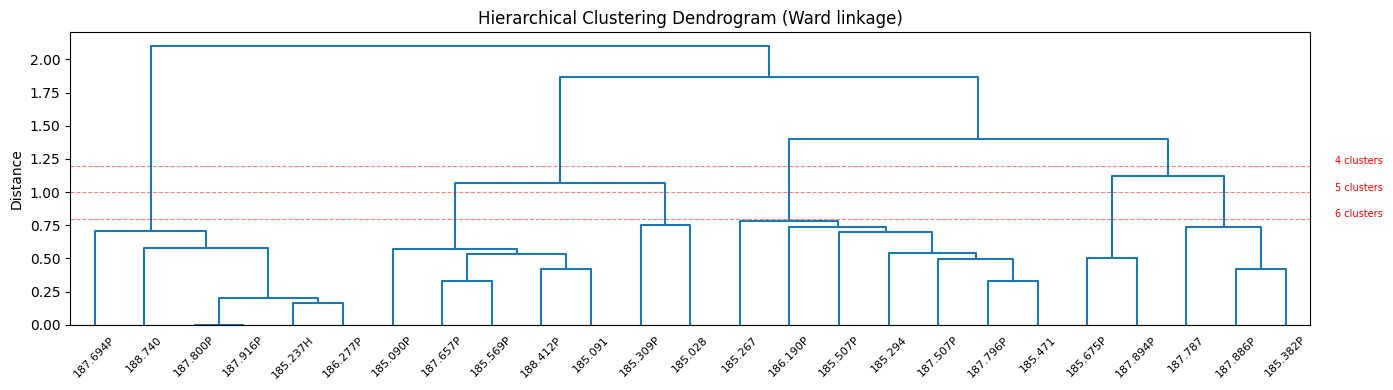

Dendrogram saved.


In [6]:
# Convert symmetric dissimilarity matrix to condensed form for scipy
condensed = squareform(dissimilarity, checks=False)

# Ward linkage
Z = linkage(condensed, method='ward')

# Plot dendrogram to see where to cut
fig, ax = plt.subplots(figsize=(14, 4))
dendrogram(
    Z,
    labels=product_names,
    ax=ax,
    color_threshold=0.0,
    leaf_rotation=45,
    leaf_font_size=8,
)
ax.set_title('Hierarchical Clustering Dendrogram (Ward linkage)', fontsize=12)
ax.set_ylabel('Distance')

# Mark candidate thresholds
for t, label in [(1.2, '4 clusters'), (1.0, '5 clusters'), (0.8, '6 clusters')]:
    ax.axhline(y=t, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.text(len(product_names)*10 + 5, t + 0.01, label, fontsize=7, color='red')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'v17_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dendrogram saved.')

In [7]:
# Try multiple thresholds to see cluster counts
print('Threshold → number of clusters:')
for t in np.arange(0.5, 2.0, 0.1):
    labels = fcluster(Z, t=t, criterion='distance')
    n_clusters = len(np.unique(labels))
    print(f'  threshold={t:.1f}  →  {n_clusters} clusters')

Threshold → number of clusters:
  threshold=0.5  →  16 clusters
  threshold=0.6  →  12 clusters
  threshold=0.7  →  11 clusters
  threshold=0.8  →  6 clusters
  threshold=0.9  →  6 clusters
  threshold=1.0  →  6 clusters
  threshold=1.1  →  5 clusters
  threshold=1.2  →  4 clusters
  threshold=1.3  →  4 clusters
  threshold=1.4  →  4 clusters
  threshold=1.5  →  3 clusters
  threshold=1.6  →  3 clusters
  threshold=1.7  →  3 clusters
  threshold=1.8  →  3 clusters
  threshold=1.9  →  2 clusters


## 5. MDS Plot with Threshold Clusters

The reference XLStat image shows the **STATIS consensus map** with cluster ellipses.
We reproduce this using our MDS coordinates + threshold-cut clusters.

Adjust `THRESHOLD` below to get the cluster granularity closest to the reference image.

In [8]:
def confidence_ellipse(x, y, ax, n_std=1.5, **kwargs):
    """Draw a covariance-based confidence ellipse for scatter points."""
    if len(x) < 2:
        ax.scatter(x, y, s=80, **{k: v for k, v in kwargs.items() if k in ['color', 'facecolor']})
        return
    cov = np.cov(x, y)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(np.abs(eigenvalues))
    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=max(width, 0.01),
        height=max(height, 0.01),
        angle=angle,
        **kwargs,
    )
    ax.add_patch(ellipse)


def plot_mds_map(
    coords,
    product_names,
    cluster_labels,
    threshold,
    title_suffix='',
    use_xlstat=False,
    xlstat_coords=None,
    xlstat_products=None,
):
    """Create the reference-style MDS scatter map."""
    n_clusters = len(np.unique(cluster_labels))
    colors = CLUSTER_COLORS[:n_clusters]

    fig, ax = plt.subplots(figsize=(11, 8))
    ax.set_facecolor('#FAFAFA')
    fig.patch.set_facecolor('white')

    # Draw axes through origin
    ax.axhline(0, color='#CCCCCC', linewidth=0.8, zorder=1)
    ax.axvline(0, color='#CCCCCC', linewidth=0.8, zorder=1)

    # Plot per cluster
    plot_coords = xlstat_coords if use_xlstat else coords
    plot_names = xlstat_products if use_xlstat else product_names

    for c_idx, cluster_id in enumerate(sorted(np.unique(cluster_labels))):
        mask = cluster_labels == cluster_id
        cx = plot_coords[mask, 0]
        cy = plot_coords[mask, 1]
        color = colors[c_idx % len(colors)]

        # Confidence ellipse (1.5 std)
        confidence_ellipse(
            cx, cy, ax,
            n_std=1.5,
            facecolor=color,
            alpha=0.15,
            edgecolor=color,
            linewidth=1.5,
            linestyle='--',
            zorder=2,
        )

        # Points
        ax.scatter(cx, cy, color=color, s=70, zorder=4, edgecolors='white', linewidths=0.8)

        # Labels
        for i, name in enumerate(np.array(plot_names)[mask]):
            ax.annotate(
                name,
                (cx[i], cy[i]),
                fontsize=7.5,
                ha='center',
                va='bottom',
                xytext=(0, 5),
                textcoords='offset points',
                color=color,
                fontweight='semibold',
                zorder=5,
            )

    # Legend
    legend_patches = [
        mpatches.Patch(color=colors[i], label=f'Cluster {i+1}', alpha=0.8)
        for i in range(n_clusters)
    ]
    ax.legend(handles=legend_patches, loc='upper right', fontsize=9, framealpha=0.9)

    coord_label = 'XLStat STATIS' if use_xlstat else 'Python MDS'
    ax.set_xlabel(f'Dimension 1  ({coord_label})', fontsize=10)
    ax.set_ylabel(f'Dimension 2  ({coord_label})', fontsize=10)
    ax.set_title(
        f'Free Sorting Consensus Map — Threshold={threshold:.2f}  ({n_clusters} clusters){title_suffix}',
        fontsize=12,
        fontweight='bold',
    )
    ax.grid(True, alpha=0.2, linewidth=0.5)

    plt.tight_layout()
    return fig

print('Helper functions defined.')

Helper functions defined.


In [9]:
# ============================================================
# CHOOSE THRESHOLD HERE
# Lower = more clusters (more granular), Higher = fewer clusters
# ============================================================
THRESHOLD = 1.2  # adjust to match reference image cluster count

cluster_labels = fcluster(Z, t=THRESHOLD, criterion='distance')
n_clusters = len(np.unique(cluster_labels))
print(f'Threshold={THRESHOLD:.2f}  →  {n_clusters} clusters')
print()
for c in sorted(np.unique(cluster_labels)):
    members = [product_names[i] for i in range(n) if cluster_labels[i] == c]
    print(f'  Cluster {c}: {members}')

Threshold=1.20  →  4 clusters

  Cluster 1: ['188.740', '187.800P', '185.237H', '186.277P', '187.916P', '187.694P']
  Cluster 2: ['185.090P', '185.309P', '188.412P', '185.091', '187.657P', '185.569P', '185.028']
  Cluster 3: ['186.190P', '187.796P', '187.507P', '185.294', '185.507P', '185.471', '185.267']
  Cluster 4: ['187.886P', '185.382P', '187.787', '185.675P', '187.894P']


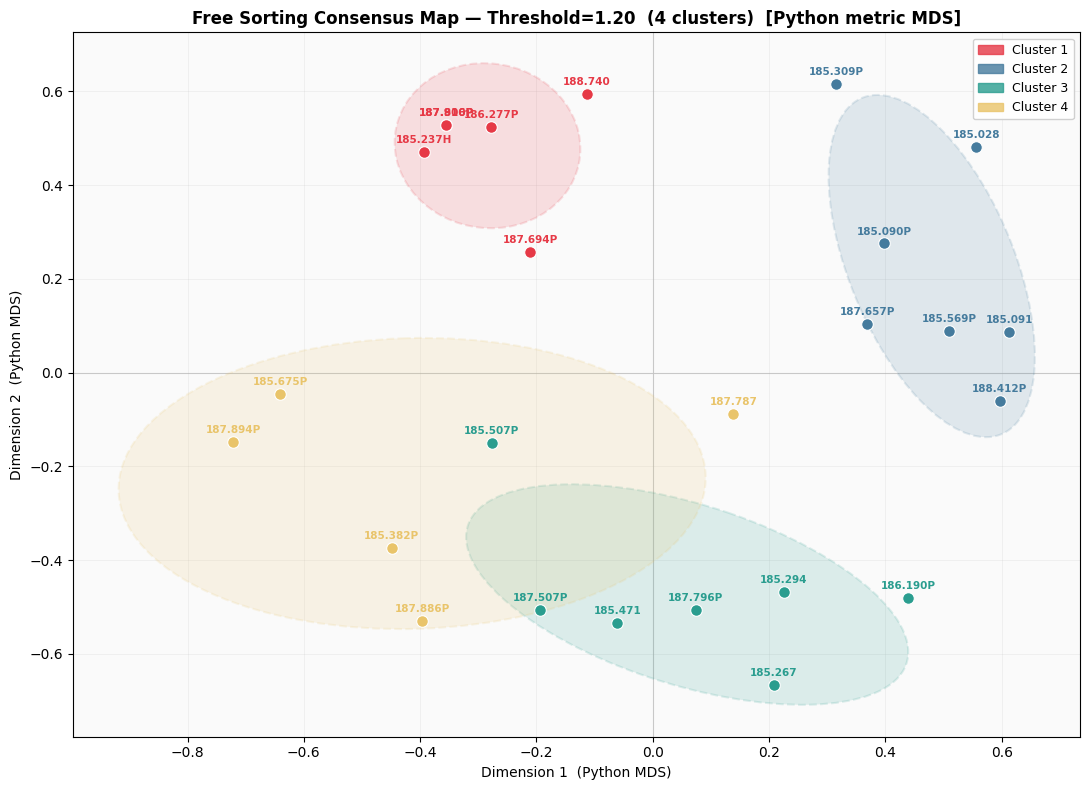

Plot A saved.


In [10]:
# --- Plot A: Python MDS coordinates ---
fig_a = plot_mds_map(
    coords=coords,
    product_names=product_names,
    cluster_labels=cluster_labels,
    threshold=THRESHOLD,
    title_suffix='  [Python metric MDS]',
    use_xlstat=False,
)
fig_a.savefig(OUTPUT_DIR / 'v17_mds_python.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot A saved.')

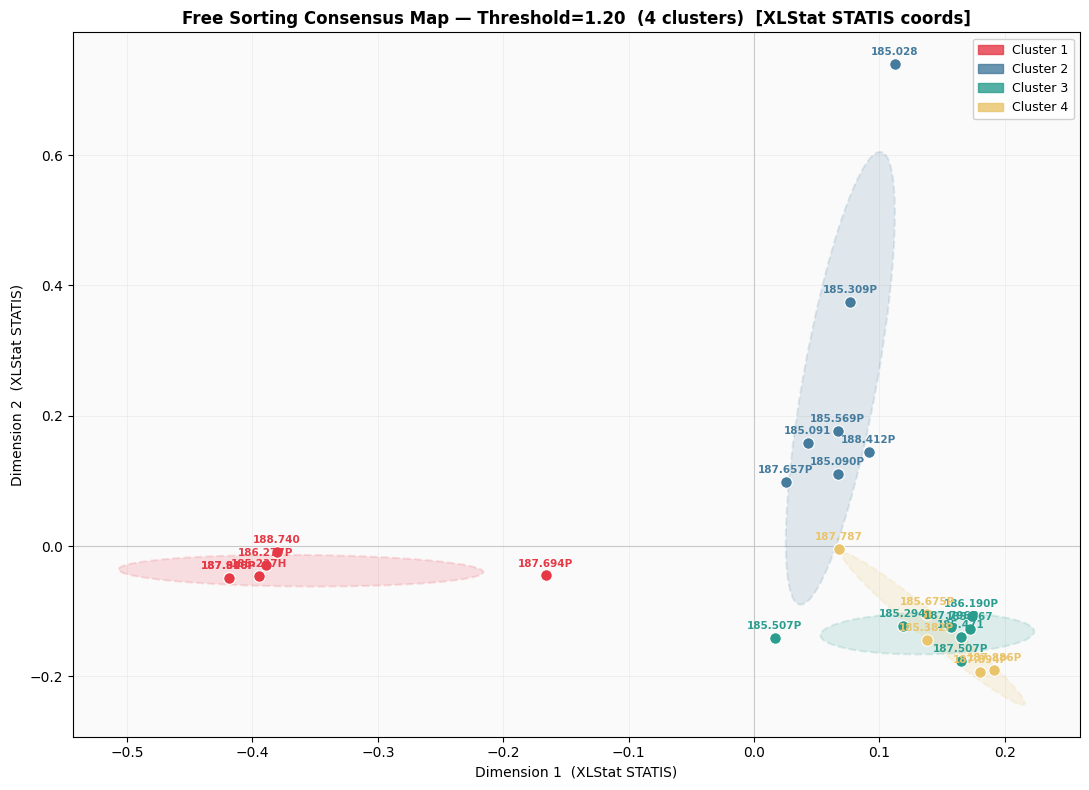

Plot B saved — this uses the SAME coordinates as the XLStat reference image.


In [11]:
# --- Plot B: XLStat STATIS coordinates (closest match to reference image) ---
# Align cluster labels to xlstat product order
xlstat_cluster_labels = np.array(
    [cluster_labels[product_names.index(p)] for p in xlstat_products]
)

fig_b = plot_mds_map(
    coords=xlstat_coords,
    product_names=xlstat_products,
    cluster_labels=xlstat_cluster_labels,
    threshold=THRESHOLD,
    title_suffix='  [XLStat STATIS coords]',
    use_xlstat=True,
    xlstat_coords=xlstat_coords,
    xlstat_products=xlstat_products,
)
fig_b.savefig(OUTPUT_DIR / 'v17_mds_xlstat_coords.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot B saved — this uses the SAME coordinates as the XLStat reference image.')

## 6. Threshold Sensitivity — Side-by-Side Grid

Show how cluster boundaries change with different thresholds.

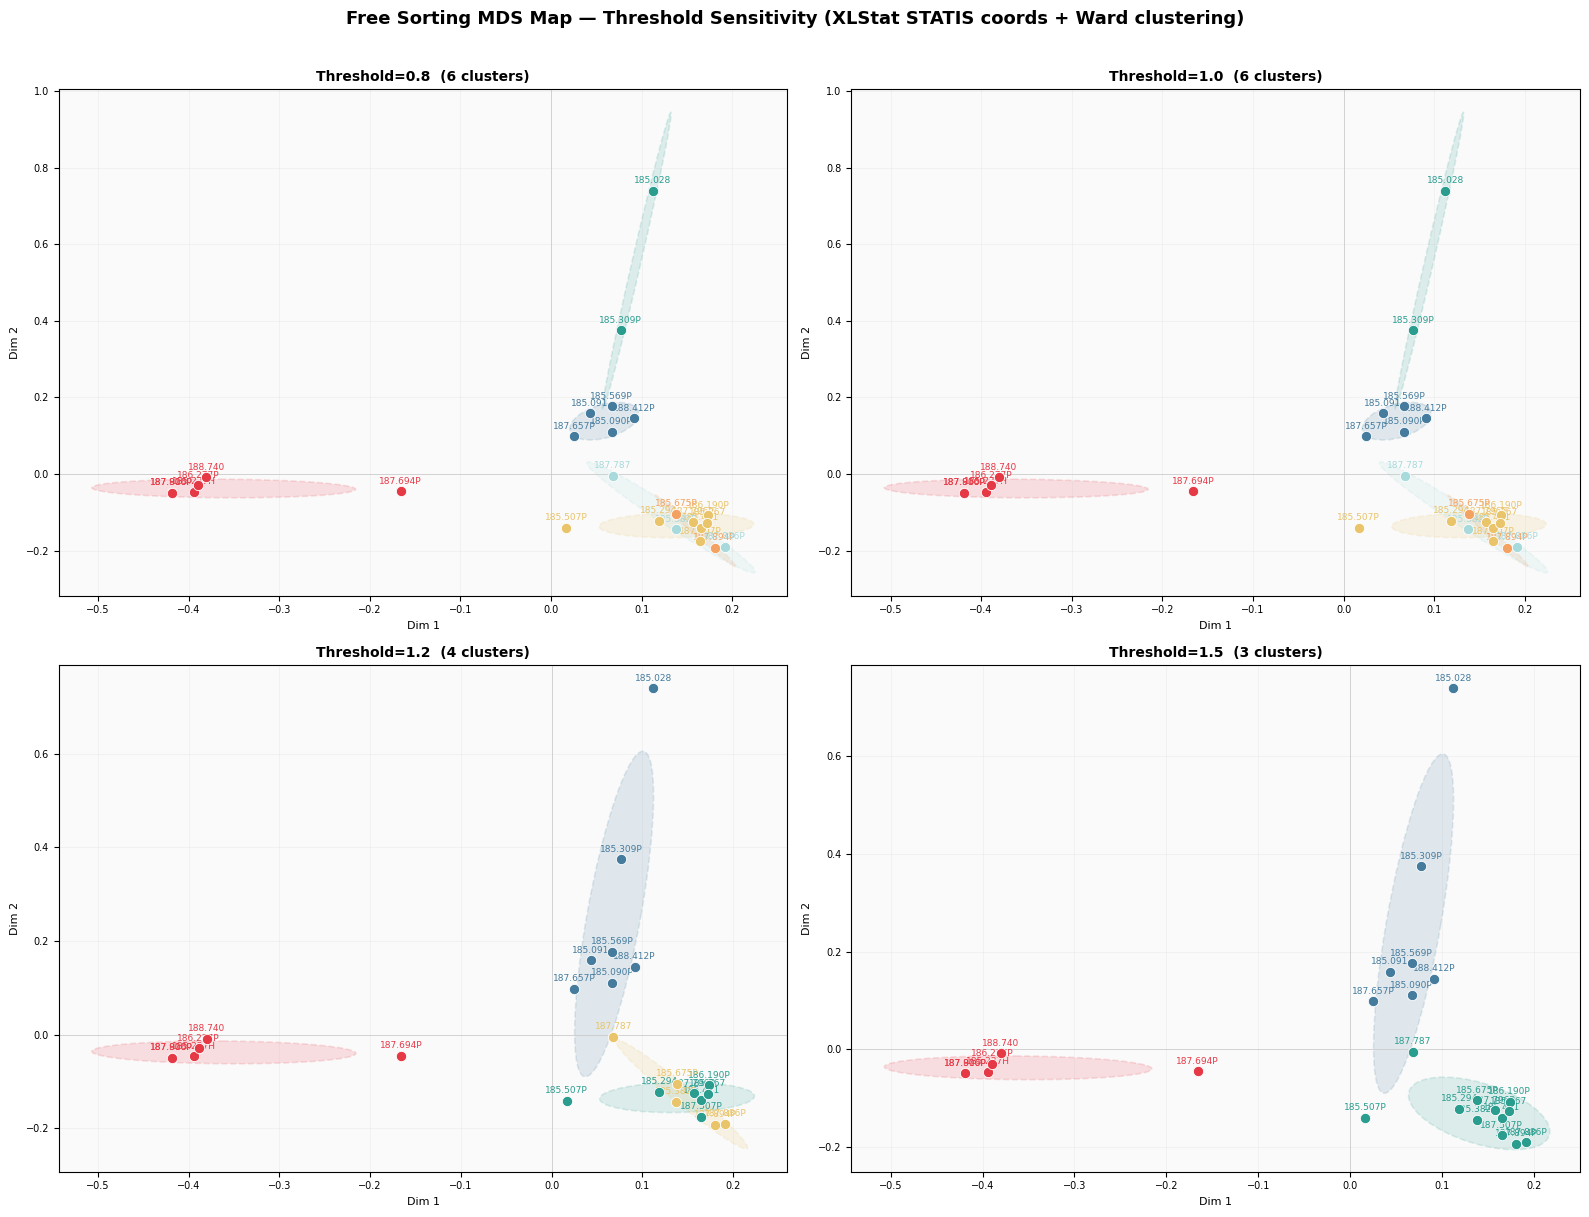

Threshold grid saved.


In [12]:
thresholds = [0.8, 1.0, 1.2, 1.5]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax_idx, t in enumerate(thresholds):
    labels_t = fcluster(Z, t=t, criterion='distance')
    n_c = len(np.unique(labels_t))
    ax = axes[ax_idx]
    ax.set_facecolor('#FAFAFA')
    ax.axhline(0, color='#CCCCCC', linewidth=0.6)
    ax.axvline(0, color='#CCCCCC', linewidth=0.6)

    # Align to xlstat product order
    labels_xlstat = np.array([labels_t[product_names.index(p)] for p in xlstat_products])
    colors = CLUSTER_COLORS[:n_c]

    for c_idx, cluster_id in enumerate(sorted(np.unique(labels_xlstat))):
        mask = labels_xlstat == cluster_id
        cx = xlstat_coords[mask, 0]
        cy = xlstat_coords[mask, 1]
        color = colors[c_idx % len(colors)]
        confidence_ellipse(cx, cy, ax, n_std=1.5,
                           facecolor=color, alpha=0.15,
                           edgecolor=color, linewidth=1.2, linestyle='--')
        ax.scatter(cx, cy, color=color, s=55, zorder=4, edgecolors='white', linewidths=0.6)
        for i, name in enumerate(np.array(xlstat_products)[mask]):
            ax.annotate(name, (cx[i], cy[i]), fontsize=6.5, ha='center', va='bottom',
                        xytext=(0, 4), textcoords='offset points', color=color)

    ax.set_title(f'Threshold={t:.1f}  ({n_c} clusters)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Dim 1', fontsize=8)
    ax.set_ylabel('Dim 2', fontsize=8)
    ax.grid(True, alpha=0.2, linewidth=0.4)
    ax.tick_params(labelsize=7)

fig.suptitle(
    'Free Sorting MDS Map — Threshold Sensitivity (XLStat STATIS coords + Ward clustering)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'v17_threshold_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Threshold grid saved.')

## 7. Key Findings

### Method
- **Data source**: Free Sorting7 (panelists P2, P4, P5, P6 — 3 sessions each = 12 judgements per product)
- **Dissimilarity**: proportion of assessors who placed two products in *different* groups
- **Map**: 2D MDS (metric) on dissimilarity matrix — same principle as XLStat's STATIS consensus map
- **Clusters**: Ward hierarchical clustering cut at a distance **threshold**

### Plots produced
- `v17_dendrogram.png` — full dendrogram with candidate threshold lines
- `v17_mds_python.png` — Python MDS coordinates + threshold clusters
- `v17_mds_xlstat_coords.png` — XLStat STATIS coordinates + threshold clusters (closest to reference image)
- `v17_threshold_grid.png` — 2×2 grid showing how clusters change with threshold

### Connection to threshold
The threshold replaces the subjective dendrogram cut that XLStat requires manually.
Lowering the threshold gives more granular clusters; raising it merges them.
The plot `v17_mds_xlstat_coords.png` uses the **exact same X/Y positions** as the reference image,
with threshold-defined cluster ellipses overlaid — making it directly comparable.